# Importations et Chargement des données brutes

In [2]:
# Importations
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

In [3]:
# Chargement
fichier_sav = "CMIR71FL.sav"
df_raw, meta = pyreadstat.read_sav(fichier_sav)
df_raw.columns = df_raw.columns.str.lower().str.replace('$', '_', regex=False)

print(f"Chargement réussi. Lignes : {df_raw.shape[0]}, Colonnes : {df_raw.shape[1]}")

Chargement réussi. Lignes : 14677, Colonnes : 5102


# Construction rigoureuse de mort_adulte

Ici, nous appliquons les trois conditions cumulatives (Décès récent, Âge adulte, Indicateur de décès) avant toute analyse.

In [4]:
# Sélection des variables nécessaires
vars_selection = ['caseid', 'v005', 'v021', 'v025', 'v024', 'v106', 'v190', 
                  'v501', 'v130', 'v463a', 'v481', 'v113', 'v116', 'v008']
df_femme = df_raw[vars_selection].copy()

# Création explicite de la colonne poids
df_femme['poids'] = df_femme['v005'] / 1000000.0

# Extraction et transformation fratrie (Wide to Long)
# On inclut mm2 (statut), mm3 (âge actuel), mm6 (années depuis décès), mm7 (âge au décès)
cols_fratrie = ['caseid'] + [col for col in df_raw.columns if col.startswith(('mm1_', 'mm2_', 'mm3_', 'mm6_', 'mm7_'))]
df_fratrie = pd.wide_to_long(
    df_raw[cols_fratrie], stubnames=['mm1', 'mm2', 'mm3', 'mm6', 'mm7'], 
    i='caseid', j='fratrie_idx', sep='_', suffix='\d+'
).reset_index().dropna(subset=['mm1'])

# Fusion
df = pd.merge(df_fratrie, df_femme, on='caseid', how='left')

# Construction de la variable mort_adulte selon les conditions :
# 1. Décès (mm2 == 0)
# 2. Âge au décès (mm7) entre 15 et 59 ans
# 3. Décès dans les 7 dernières années (mm6 <= 7)
df['mort_adulte'] = np.where(
    (df['mm2'] == 0) & 
    (df['mm7'] >= 15) & 
    (df['mm7'] <= 59) & 
    (df['mm6'] <= 7), 
    1, 0
)

# Filtre : Garder les survivants (mm2 == 1) ET les décès adultes récents (mort_adulte == 1)
df = df[(df['mm2'] == 1) | (df['mort_adulte'] == 1)].copy()

# Calcul de l'âge unifié pour le modèle
# Si vivant (mm2 == 1), on prend l'âge actuel (mm3). Si mort (mm2 == 0), on prend l'âge au décès (mm7).
df['age'] = np.where(df['mm2'] == 1, df['mm3'], df['mm7'])

print(f"Nombre de cas après filtrage : {len(df)}")
print(f"Nombre de décès adultes identifiés : {df['mort_adulte'].sum()}")
print(f"Colonnes disponibles pour l'export : {list(df.columns)}")

Nombre de cas après filtrage : 61151
Nombre de décès adultes identifiés : 1684
Colonnes disponibles pour l'export : ['caseid', 'fratrie_idx', 'mm1', 'mm2', 'mm3', 'mm6', 'mm7', 'v005', 'v021', 'v025', 'v024', 'v106', 'v190', 'v501', 'v130', 'v463a', 'v481', 'v113', 'v116', 'v008', 'poids', 'mort_adulte', 'age']


# Visualisation de la cible

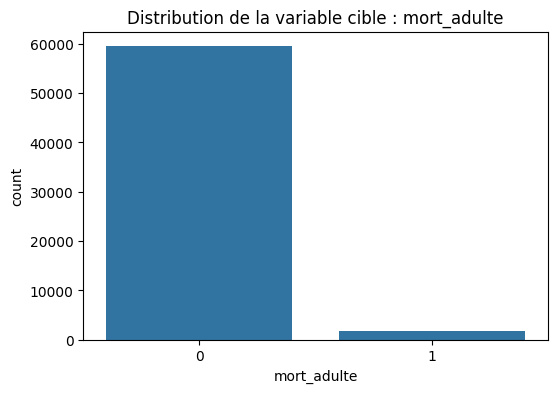

mort_adulte
0    59467
1     1684
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='mort_adulte', data=df)
plt.title('Distribution de la variable cible : mort_adulte')
plt.show()
print(df['mort_adulte'].value_counts())


--- Analyse univariee : Sexe du frère ou de la sœur ---


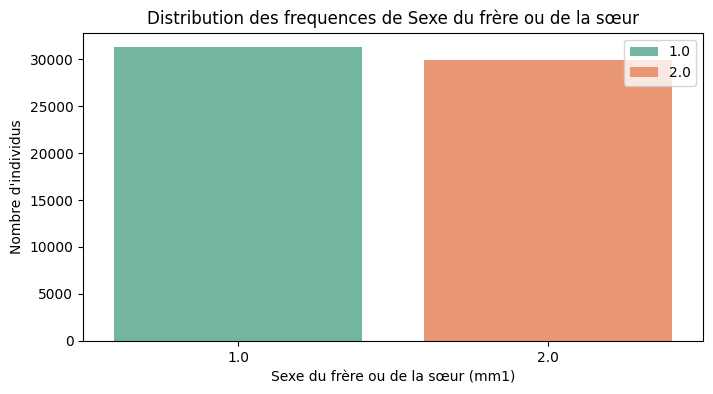


--- Analyse univariee : Niveau d'instruction ---


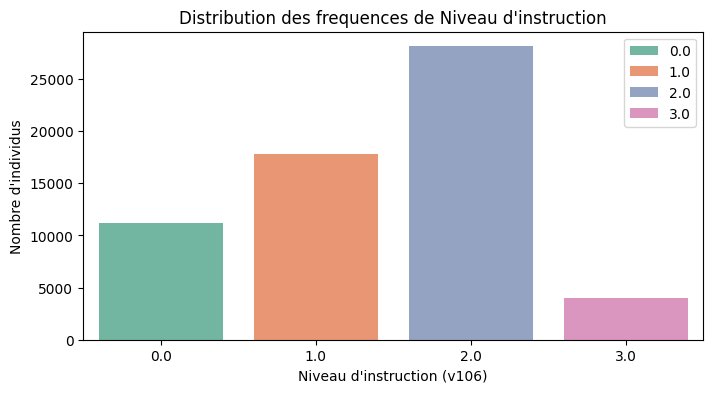


--- Analyse univariee : Quintile de richesse ---


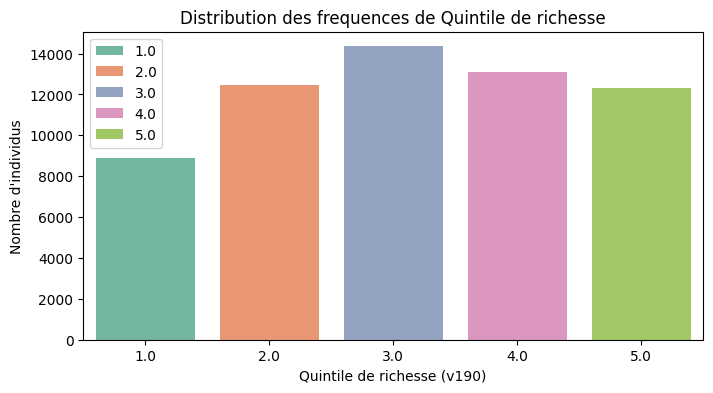


--- Analyse univariee : Milieu de résidence ---


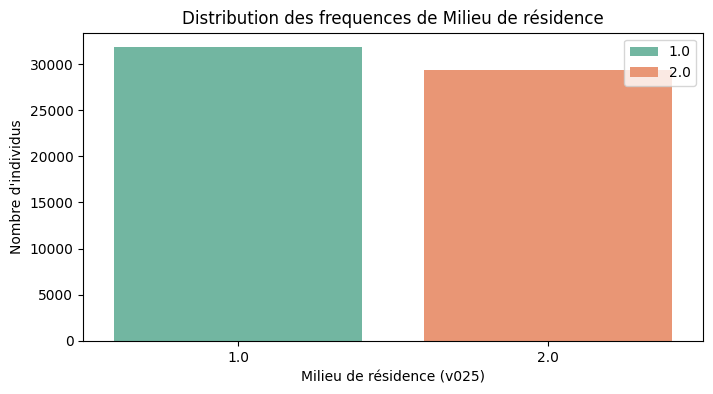


--- Analyse univariee : Région ---


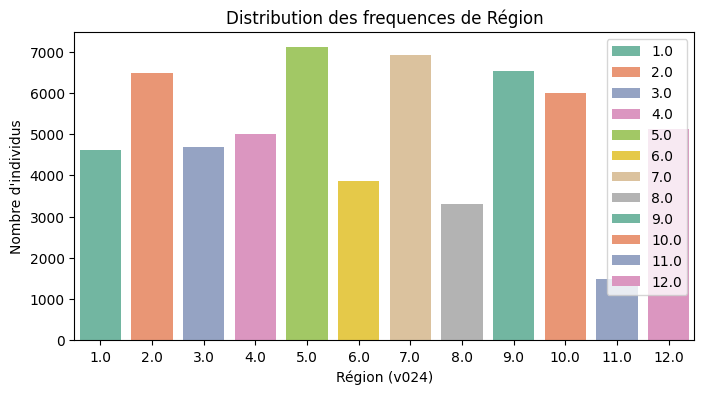


--- Analyse univariee : Statut matrimonial ---


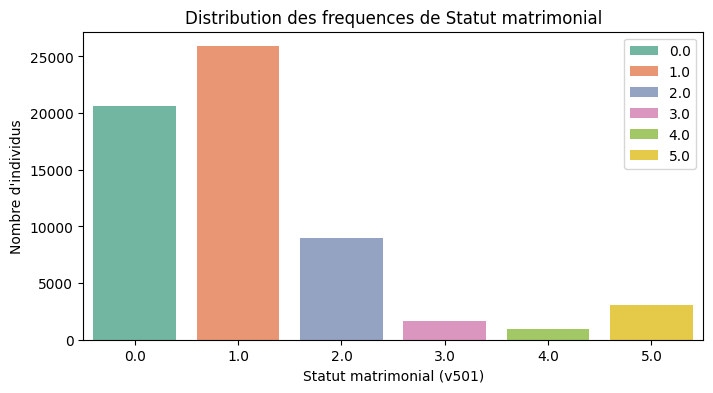


--- Analyse univariee : Religion ---


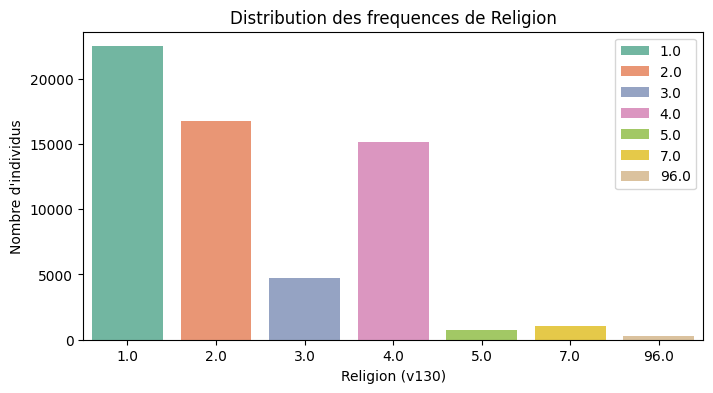


--- Analyse univariee : Tabagisme ---


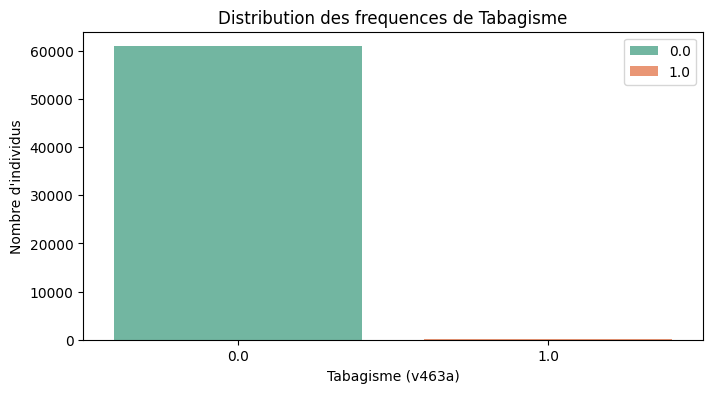


--- Analyse univariee : Assurance ---


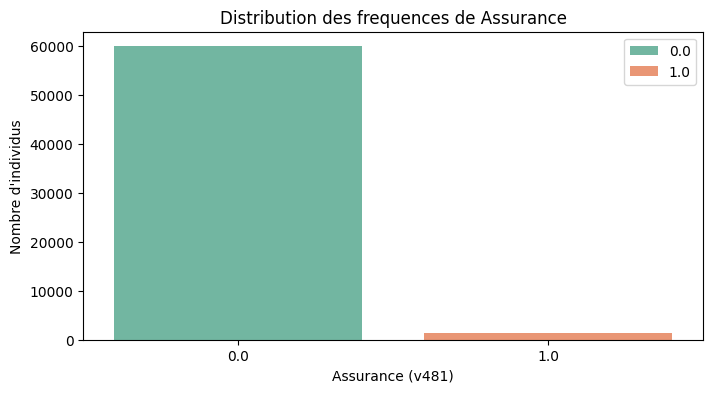


--- Analyse univariee : Source d'eau ---


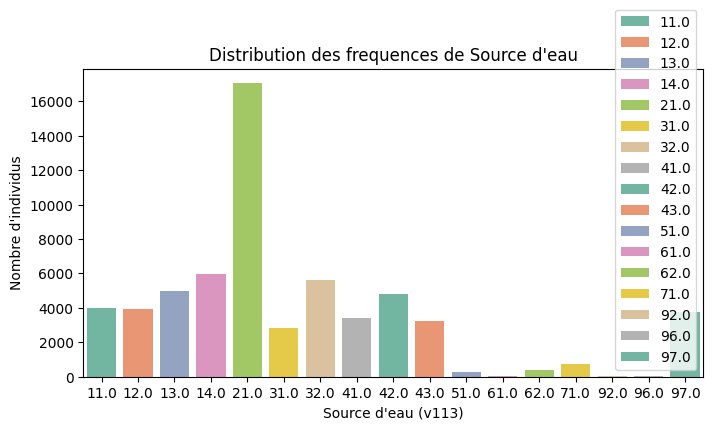


--- Analyse univariee : Type d'installation sanitaire ---


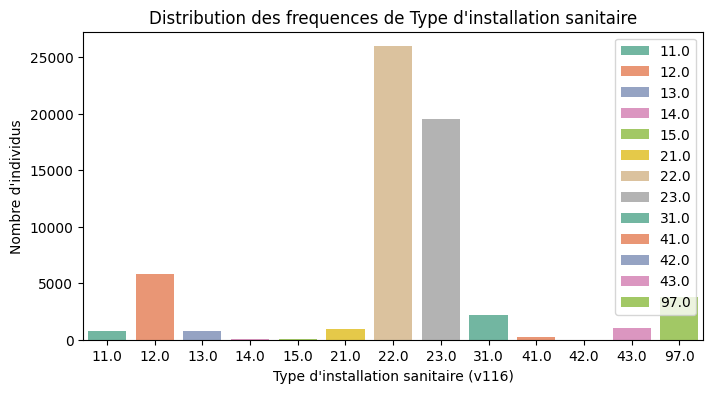

In [6]:
# Liste des variables catégorielles à analyser (excluant 'age' et 'poids')
variables_x = ['mm1', 'v106', 'v190', 'v025', 'v024', 'v501', 'v130', 'v463a', 'v481', 'v113', 'v116']
label_x = ['Sexe du frère ou de la sœur', 'Niveau d\'instruction', 'Quintile de richesse', 'Milieu de résidence',
           'Région', 'Statut matrimonial', 'Religion', 'Tabagisme', 'Assurance', 'Source d\'eau', 'Type d\'installation sanitaire']

for var, label in zip(variables_x, label_x):
    if var in df.columns:
        print(f"\n--- Analyse univariee : {label} ---")
        
        # 2. Frequence des variables categorielles
        plt.figure(figsize=(8, 4))
        # On utilise barplot qui calcule automatiquement la moyenne (le risque)
        sns.countplot(x=var, data=df, palette='Set2', hue=var)
        #plt.axhline(df['mort_adulte'].mean(), color='red', linestyle='--', label='Moyenne globale')
        plt.title(f'Distribution des frequences de {label}')
        plt.xlabel(f'{label} ({var})' )
        plt.ylabel('Nombre d\'individus')
        plt.legend()
        plt.show()
    else:
        print(f"La variable {var} n'est pas présente dans le dataframe.")

# Analyse Univariée (Test de dépendance)

On sélectionne ici les variables statistiquement liées à la mortalité (Chi-carré pour les catégorielles, ANOVA pour l'âge)

In [7]:
candidates = ['mm1', 'v106', 'v190', 'v025', 'v024', 'v501', 'v130', 'v463a', 'v481', 'v113', 'v116']
significatives = []

for var in candidates:
    cont = pd.crosstab(df[var], df['mort_adulte'])
    chi2, p, _, _ = chi2_contingency(cont)
    if p < 0.05:
        significatives.append(var)
        print(f"Variable {var} retenue (p={p:.6f})")

Variable v106 retenue (p=0.000000)
Variable v190 retenue (p=0.000007)
Variable v024 retenue (p=0.000000)
Variable v501 retenue (p=0.000000)
Variable v130 retenue (p=0.042970)
Variable v463a retenue (p=0.000004)
Variable v113 retenue (p=0.001002)
Variable v116 retenue (p=0.009980)


# Analyse Bivariée (Graphiques)


--- Analyse : mort_adulte vs Sexe du frère ou de la sœur ---
Test du Khi-deux : Chi2=1.17, p-value=0.2790


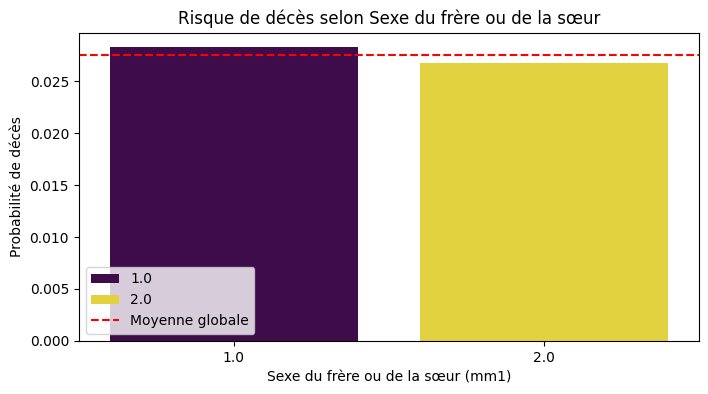


--- Analyse : mort_adulte vs Niveau d'instruction ---
Test du Khi-deux : Chi2=103.72, p-value=0.0000


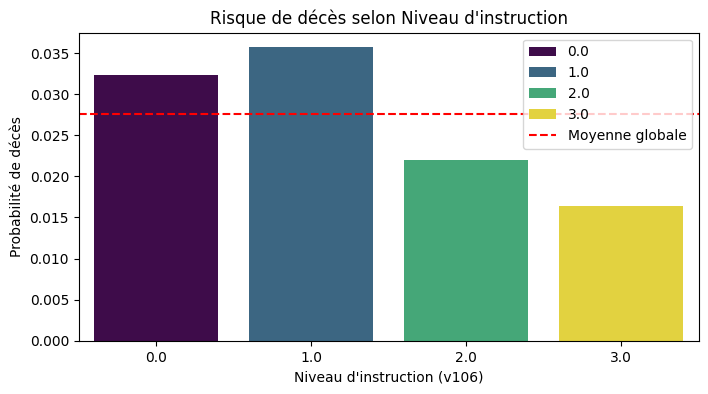


--- Analyse : mort_adulte vs Quintile de richesse ---
Test du Khi-deux : Chi2=29.35, p-value=0.0000


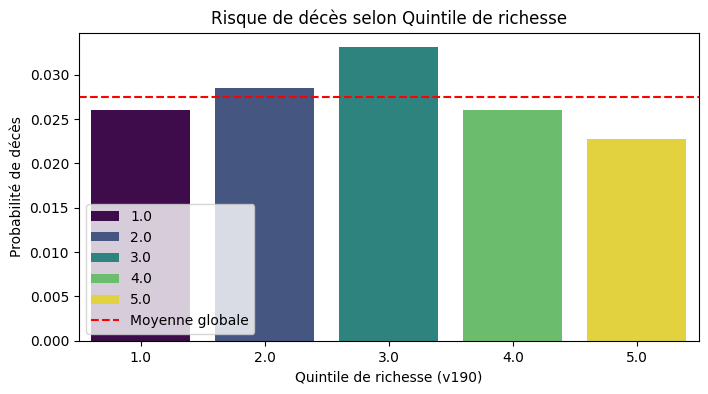


--- Analyse : mort_adulte vs Milieu de résidence ---
Test du Khi-deux : Chi2=0.26, p-value=0.6091


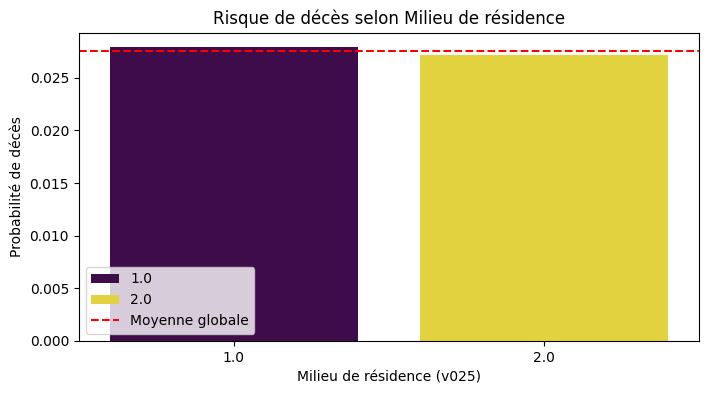


--- Analyse : mort_adulte vs Région ---
Test du Khi-deux : Chi2=114.01, p-value=0.0000


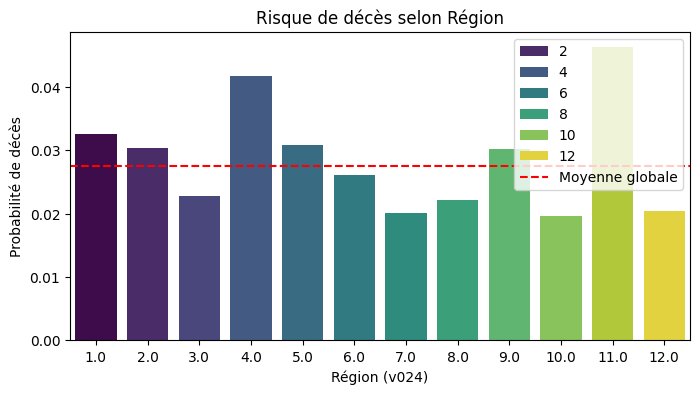


--- Analyse : mort_adulte vs Statut matrimonial ---
Test du Khi-deux : Chi2=286.88, p-value=0.0000


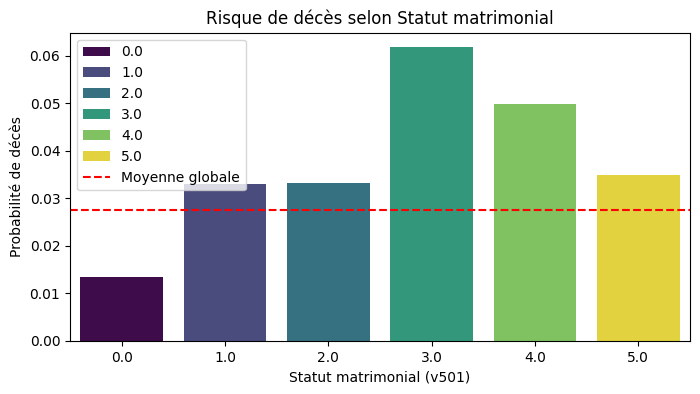


--- Analyse : mort_adulte vs Religion ---
Test du Khi-deux : Chi2=13.00, p-value=0.0430


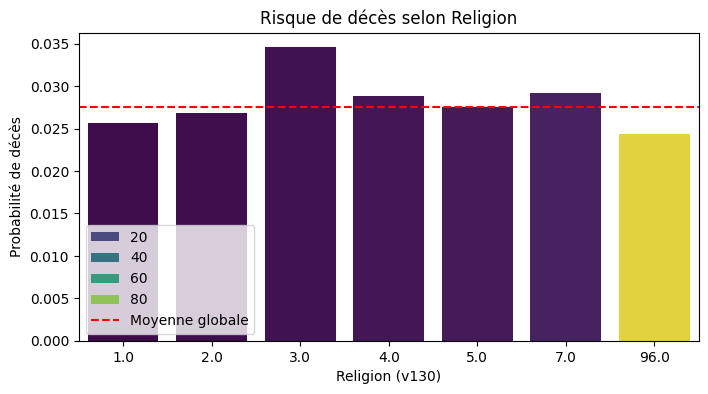


--- Analyse : mort_adulte vs Tabagisme ---
Test du Khi-deux : Chi2=21.48, p-value=0.0000


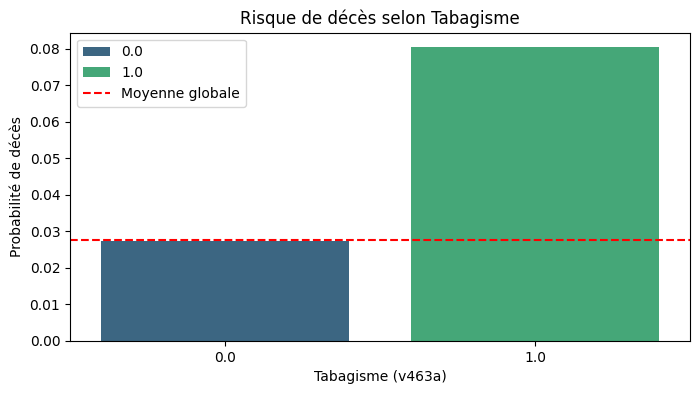


--- Analyse : mort_adulte vs Assurance ---
Test du Khi-deux : Chi2=0.00, p-value=1.0000


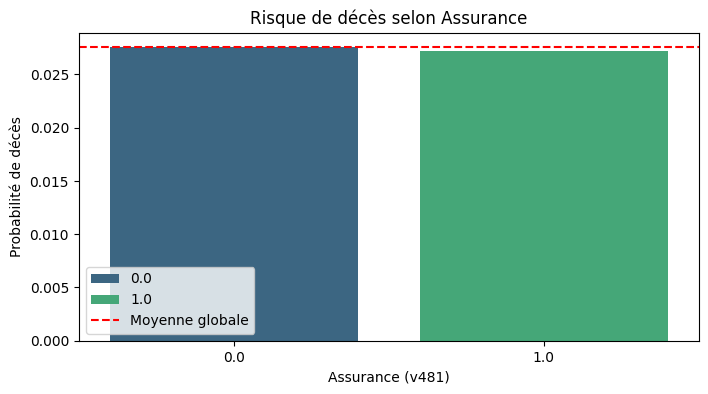


--- Analyse : mort_adulte vs Source d'eau ---
Test du Khi-deux : Chi2=39.25, p-value=0.0010


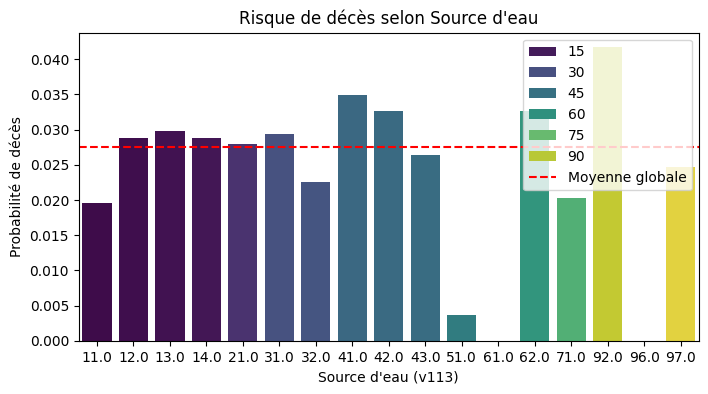


--- Analyse : mort_adulte vs Type d'installation sanitaire ---
Test du Khi-deux : Chi2=26.22, p-value=0.0100


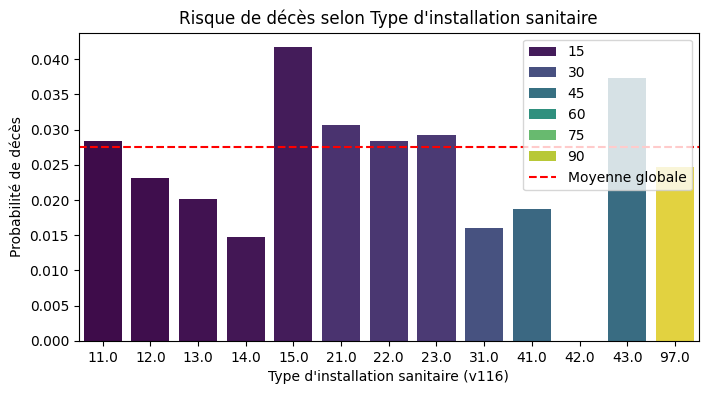

In [8]:
# Liste des variables catégorielles à analyser (excluant 'age' et 'poids')
variables_x = ['mm1', 'v106', 'v190', 'v025', 'v024', 'v501', 'v130', 'v463a', 'v481', 'v113', 'v116']
label_x = ['Sexe du frère ou de la sœur', 'Niveau d\'instruction', 'Quintile de richesse', 'Milieu de résidence',
           'Région', 'Statut matrimonial', 'Religion', 'Tabagisme', 'Assurance', 'Source d\'eau', 'Type d\'installation sanitaire']


for var, label in zip(variables_x, label_x):
    if var in df.columns:
        print(f"\n--- Analyse : mort_adulte vs {label} ---")
        
        # 1. Test du Khi-deux
        contingency = pd.crosstab(df[var], df['mort_adulte'])
        chi2, p_val, dof, expected = chi2_contingency(contingency)
        print(f"Test du Khi-deux : Chi2={chi2:.2f}, p-value={p_val:.4f}")
        
        # 2. Graphique : Risque de décès (moyenne de mort_adulte par catégorie)
        plt.figure(figsize=(8, 4))
        # On utilise barplot qui calcule automatiquement la moyenne (le risque)
        sns.barplot(x=var, y='mort_adulte', data=df, errorbar=None, palette='viridis', hue=var)
        plt.axhline(df['mort_adulte'].mean(), color='red', linestyle='--', label='Moyenne globale')
        plt.title(f'Risque de décès selon {label}')
        plt.ylabel('Probabilité de décès')
        plt.xlabel(f'{label} ({var})')
        plt.legend()
        plt.show()
    else:
        print(f"La variable {var} n'est pas présente dans le dataframe.")

# Analyse multivariee

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Préparation du dataframe : sélection des colonnes et suppression des valeurs manquantes
cols_ml = ['mort_adulte', 'age', 'v106', 'v190', 'v024', 'v501', 'v130', 'v463a', 'v113', 'v116']
df_model = df[cols_ml].dropna().copy()

# 1. Regroupement des modalités rares ou trop nombreuses
# Exemple pour v113 (Source d'eau) : regrouper les sources similaires
# Vous devez adapter ces dictionnaires selon vos besoins réels
df_model['v113_grouped'] = df_model['v113'].replace({
    10: 1, 11: 1, 12: 1, 13: 1, 14: 1, # Robinet/Eau courante
    20: 2, 21: 2,                     # Puits/Forage
    30: 3, 31: 3, 32: 3,              # Puits
    40: 4, 41: 4, 42: 4, 43: 4,       # Sources/Rivière
    61: 5, 62: 5, 71: 5, 92: 5        # Autres modes
})

# Exemple pour v116 (Sanitaire) :
df_model['v116_grouped'] = df_model['v116'].apply(lambda x: x // 10)

# 2. Relancer le modèle avec les variables regroupées
formula = ("mort_adulte ~ age + C(v106) + C(v190) + C(v024) + C(v501) + "
           "C(v130) + C(v463a) + C(v113_grouped) + C(v116_grouped)")

model = smf.glm(formula=formula, data=df_model, family=sm.families.Binomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            mort_adulte   No. Observations:                61151
Model:                            GLM   Df Residuals:                    61109
Model Family:                Binomial   Df Model:                           41
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7352.3
Date:                Fri, 22 May 2026   Deviance:                       14705.
Time:                        08:32:08   Pearson chi2:                 5.77e+04
No. Iterations:                    22   Pseudo R-squ. (CS):            0.01163
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Exportation pour le ML

On exporte uniquement les variables retenues pour éviter le surapprentissage (overfitting)

In [10]:
# CODE D'EXPORT CORRIGÉ
# Ne filtrez pas par 'significatives' pour le ML
cols_to_export = ['mort_adulte', 'age', 'poids', 'v021', 'v106', 'v190', 'v024', 'v501', 'v130', 'v463a', 'v113', 'v116']
df_export = df[cols_to_export].dropna()
df_export.to_csv("donnees_propres.csv", index=False)